In [2]:
import pandas as pd 
import numpy as np

In [3]:
df=pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [17]:
df["income_cat"]=pd.cut(df["median_income"],bins=[0,1.5,2.5,3.5,4.5,5.5,6,np.inf],labels=[1,2,3,4,5,6,7])

In [18]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,7
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,7
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,7
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,6
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,4


In [19]:
from sklearn.model_selection import StratifiedShuffleSplit # can do multiple splits

In [23]:
sss=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_idx,test_idx in sss.split(df,df["income_cat"]):
    train_set=df.iloc[train_idx]
    test_set=df.iloc[test_idx]

<Axes: xlabel='income_cat'>

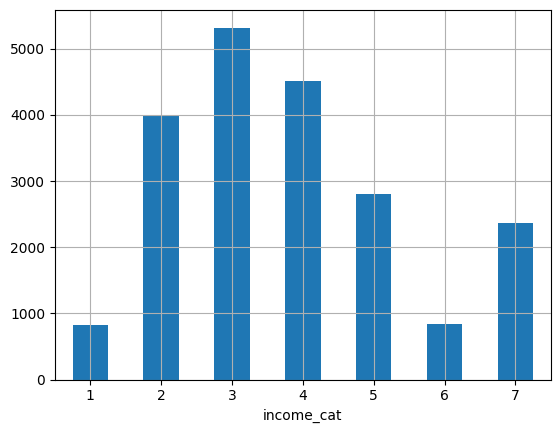

In [24]:
# behaviour check :
df["income_cat"].value_counts().sort_index().plot.bar(rot=0,grid=True)

<Axes: xlabel='income_cat'>

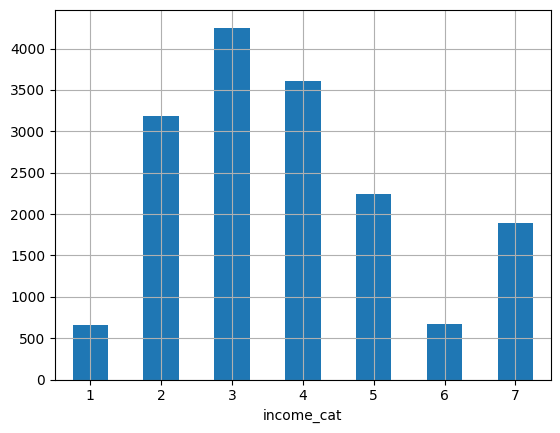

In [25]:
train_set["income_cat"].value_counts().sort_index().plot.bar(rot=0,grid=True) # same Behaviour as above

<Axes: xlabel='income_cat'>

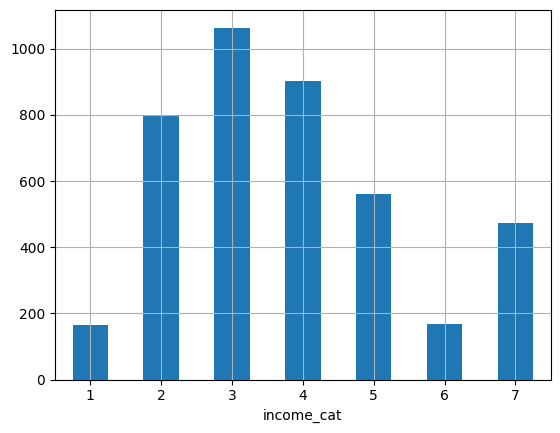

In [26]:
test_set["income_cat"].value_counts().sort_index().plot.bar(rot=0,grid=True) 